In [13]:
# Imports
%matplotlib inline
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import io

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("All imports successful")

All imports successful


In [14]:
#Load & Preprocess Data
TRAIN_PATH = "../data/ocpp_app_layer/Combined/Train.csv"
TEST_PATH  = "../data/ocpp_app_layer/Combined/Test.csv"
OUT_DIR    = "../outputs/figures"
os.makedirs(OUT_DIR, exist_ok=True)

DROP_COLS = ["flow_id", "src_ip", "dst_ip", "flow_start_timestamp", "flow_end_timestamp"]

def load_and_preprocess(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    train_df = train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns])
    test_df  = test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns])

    X_train_full = train_df.drop("label", axis=1)
    y_train_full = train_df["label"]
    X_test       = test_df.drop("label", axis=1)
    y_test       = test_df["label"]

    le = LabelEncoder()
    y_train_full_enc = le.fit_transform(y_train_full)
    y_test_enc       = le.transform(y_test)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full_enc,
        test_size=0.20, random_state=SEED, stratify=y_train_full_enc
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    return X_train_sc, X_val_sc, X_test_sc, y_train, y_val, y_test_enc, le

X_train, X_val, X_test, y_train, y_val, y_test, le = load_and_preprocess(TRAIN_PATH, TEST_PATH)
NUM_FEATURES = X_train.shape[1]
NUM_CLASSES  = len(le.classes_)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes: {list(le.classes_)}")

Train : (2416, 49)
Val   : (604, 49)
Test  : (1295, 49)
Classes: ['cyberattack_ocpp16_doc_idtag', 'cyberattack_ocpp16_dos_flooding_heartbeat', 'cyberattack_ocpp16_fdi_chargingprofile', 'cyberattack_ocpp16_unauthorized_access', 'normal']


In [15]:
# Model Definitions & Helpers

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# DataLoader helper
def to_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=32)
val_loader   = to_loader(X_val,   y_val,   batch_size=32, shuffle=False)
test_loader  = to_loader(X_test,  y_test,  batch_size=32, shuffle=False)

# Final MLP
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Small MLP (ablation)
class SmallMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Training loop
def train_model(model, train_loader, val_loader,
                lr=0.001, epochs=50, patience=10, device="cpu"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += xb.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out  = model(xb)
                loss = criterion(out, yb)
                v_loss    += loss.item() * xb.size(0)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f}  acc={train_acc:.4f} | "
                  f"val_loss={val_loss:.4f}  acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  → Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history

# Evaluate helper
def evaluate(model, loader, device="cpu"):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb   = xb.to(device)
            out  = model(xb)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("Models and helpers ready")

Using device: cpu
Models and helpers ready


In [16]:
#Baseline

print("=" * 55)
print("EXPERIMENT 1: Dummy Baseline (most-frequent class)")
print("=" * 55)

dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
dummy_acc = accuracy_score(y_val, y_pred_dummy)
dummy_f1  = f1_score(y_val, y_pred_dummy, average="macro", zero_division=0)

print(f"Validation Accuracy : {dummy_acc:.4f}")
print(f"Validation Macro F1 : {dummy_f1:.4f}")

EXPERIMENT 1: Dummy Baseline (most-frequent class)
Validation Accuracy : 0.1987
Validation Macro F1 : 0.0663


In [17]:
#Small MLP Ablation

print("=" * 55)
print("EXPERIMENT 2: Small MLP (64-32-16) — Ablation")
print("=" * 55)

small_model = SmallMLP(NUM_FEATURES, NUM_CLASSES)
small_model, small_history = train_model(
    small_model, train_loader, val_loader,
    lr=0.001, epochs=50, patience=10, device=device
)

y_true_val, y_pred_small, _ = evaluate(small_model, val_loader, device)
small_acc = accuracy_score(y_true_val, y_pred_small)
small_f1  = f1_score(y_true_val, y_pred_small, average="macro")

print(f"\nSmall MLP  Accuracy : {small_acc:.4f}")
print(f"Small MLP  Macro F1 : {small_f1:.4f}")

EXPERIMENT 2: Small MLP (64-32-16) — Ablation
Epoch   1 | train_loss=0.9237  acc=0.7918 | val_loss=0.2394  acc=0.9570
Epoch   5 | train_loss=0.0143  acc=0.9975 | val_loss=0.0104  acc=0.9983
Epoch  10 | train_loss=0.0035  acc=0.9992 | val_loss=0.0058  acc=0.9967
Epoch  15 | train_loss=0.0015  acc=1.0000 | val_loss=0.0043  acc=0.9967
Epoch  20 | train_loss=0.0045  acc=0.9996 | val_loss=0.0040  acc=0.9967
Epoch  25 | train_loss=0.0021  acc=0.9996 | val_loss=0.0051  acc=0.9967
Epoch  30 | train_loss=0.0010  acc=0.9996 | val_loss=0.0036  acc=0.9983
  → Early stopping at epoch 32

Small MLP  Accuracy : 0.9967
Small MLP  Macro F1 : 0.9967


In [18]:
# Final MLP Training & Metrics

print("=" * 55)
print("EXPERIMENT 3: Final MLP (128-64-32) — Main Model")
print("=" * 55)

t0 = time.time()
final_model = MLP(NUM_FEATURES, NUM_CLASSES)
final_model, final_history = train_model(
    final_model, train_loader, val_loader,
    lr=0.001, epochs=50, patience=10, device=device
)
train_time = time.time() - t0
print(f"\nTotal training time: {train_time:.2f}s")

# Validation
y_true_val, y_pred_val, y_probs_val = evaluate(final_model, val_loader, device)
print("\n── Validation Results ──────────────────────────────")
print(f"Accuracy : {accuracy_score(y_true_val, y_pred_val):.4f}")
print(f"Macro F1 : {f1_score(y_true_val, y_pred_val, average='macro'):.4f}")
print(f"Micro F1 : {f1_score(y_true_val, y_pred_val, average='micro'):.4f}")
print(classification_report(y_true_val, y_pred_val, target_names=le.classes_))

# Test
y_true_test, y_pred_test, y_probs_test = evaluate(final_model, test_loader, device)
print("── Test Results ─────────────────────────────────────")
print(f"Accuracy : {accuracy_score(y_true_test, y_pred_test):.4f}")
print(f"Macro F1 : {f1_score(y_true_test, y_pred_test, average='macro'):.4f}")
print(f"Micro F1 : {f1_score(y_true_test, y_pred_test, average='micro'):.4f}")
print(classification_report(y_true_test, y_pred_test, target_names=le.classes_))

auroc = roc_auc_score(y_true_test, y_probs_test, multi_class='ovr', average='macro')
print(f"AUROC (macro OvR) : {auroc:.4f}")

torch.save(final_model.state_dict(), "../outputs/mlp_final.pt")
print("\nModel saved → outputs/mlp_final.pt")

EXPERIMENT 3: Final MLP (128-64-32) — Main Model


Epoch   1 | train_loss=0.8512  acc=0.7388 | val_loss=0.0625  acc=0.9868
Epoch   5 | train_loss=0.0115  acc=0.9979 | val_loss=0.0052  acc=0.9983
Epoch  10 | train_loss=0.0089  acc=0.9996 | val_loss=0.0050  acc=0.9967
Epoch  15 | train_loss=0.0006  acc=1.0000 | val_loss=0.0036  acc=0.9967
Epoch  20 | train_loss=0.0036  acc=0.9992 | val_loss=0.0086  acc=0.9967
Epoch  25 | train_loss=0.0034  acc=0.9996 | val_loss=0.0060  acc=0.9967
  → Early stopping at epoch 26

Total training time: 2.10s

── Validation Results ──────────────────────────────
Accuracy : 0.9983
Macro F1 : 0.9983
Micro F1 : 0.9983
                                           precision    recall  f1-score   support

             cyberattack_ocpp16_doc_idtag       1.00      0.99      1.00       121
cyberattack_ocpp16_dos_flooding_heartbeat       1.00      1.00      1.00       120
   cyberattack_ocpp16_fdi_chargingprofile       1.00      1.00      1.00       121
   cyberattack_ocpp16_unauthorized_access       1.00      1.00      

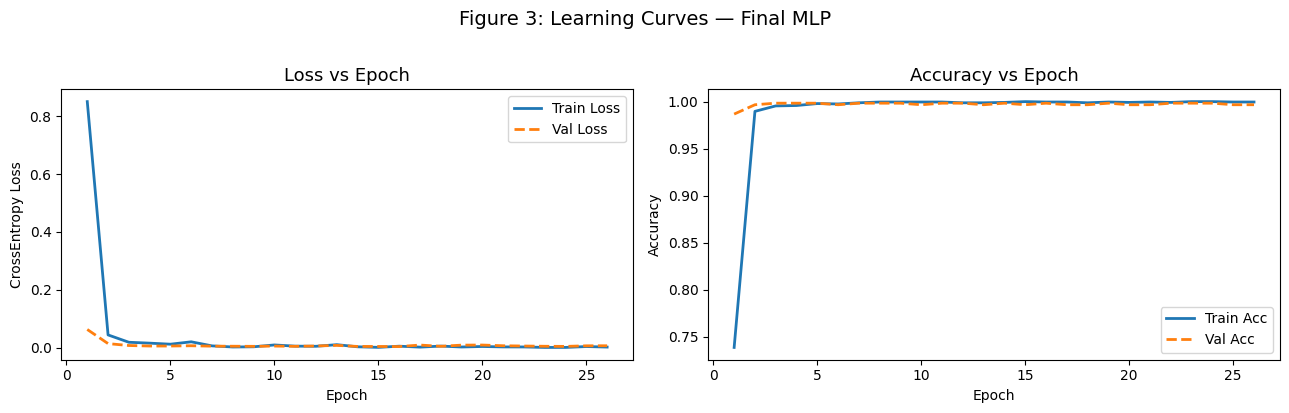

Saved: learning_curves.png


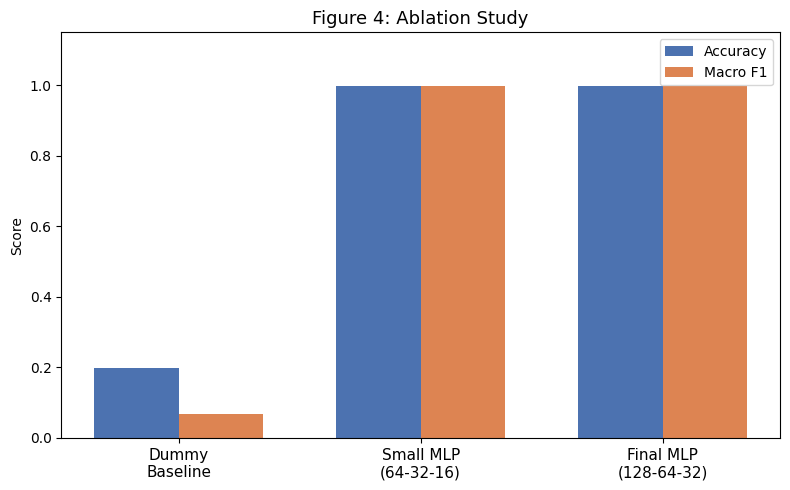

Saved: ablation_comparison.png


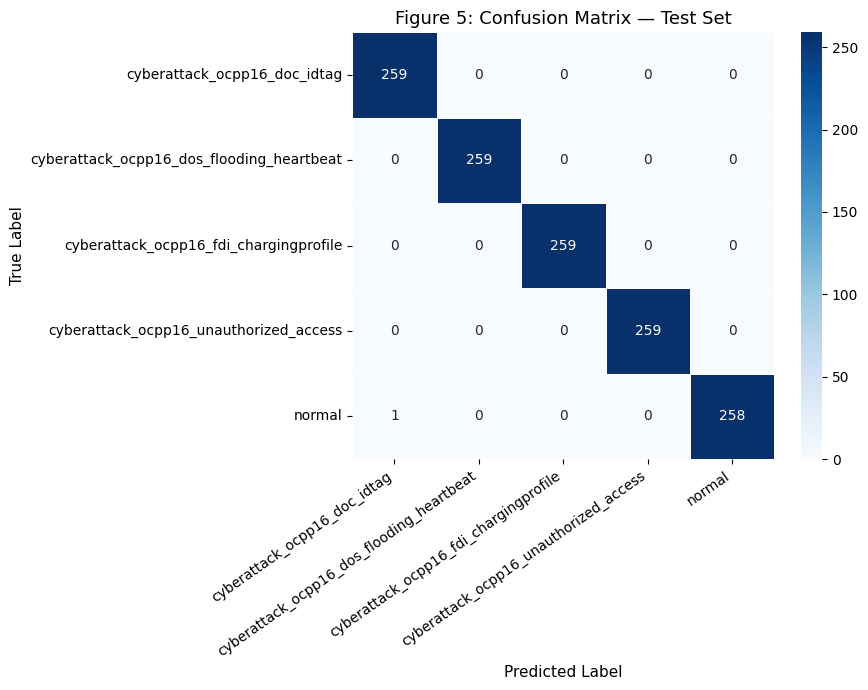

Saved: confusion_matrix.png


In [19]:
epochs_range = range(1, len(final_history["train_loss"]) + 1)

# ── Learning Curves ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, final_history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, final_history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
axes[0].set_title("Loss vs Epoch", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, final_history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(epochs_range, final_history["val_acc"],   label="Val Acc",   linewidth=2, linestyle="--")
axes[1].set_title("Accuracy vs Epoch", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Figure 3: Learning Curves — Final MLP", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: learning_curves.png")

# ── Ablation Comparison ──
model_names = ["Dummy\nBaseline", "Small MLP\n(64-32-16)", "Final MLP\n(128-64-32)"]
accs = [dummy_acc, small_acc, accuracy_score(y_true_val, y_pred_val)]
f1s  = [dummy_f1,  small_f1,  f1_score(y_true_val, y_pred_val, average="macro")]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accs, width, label="Accuracy", color="#4C72B0")
ax.bar(x + width/2, f1s,  width, label="Macro F1",  color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Figure 4: Ablation Study", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_comparison.png")

# ── Confusion Matrix ──
cm = confusion_matrix(y_true_test, y_pred_test)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("Figure 5: Confusion Matrix — Test Set", fontsize=13)
plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [20]:
#Efficiency Metrics
print("=" * 55)
print("EFFICIENCY METRICS")
print("=" * 55)

num_params = sum(p.numel() for p in final_model.parameters())
buf = io.BytesIO()
torch.save(final_model.state_dict(), buf)
disk_mb = buf.tell() / 1e6
epochs_run = len(final_history["train_loss"])

print(f"Parameters    : {num_params:,}")
print(f"Model size    : {disk_mb:.3f} MB")
print(f"Epochs run    : {epochs_run}")
print(f"Train time    : {train_time:.2f}s total  |  {train_time/epochs_run:.3f}s per epoch")

# Latency
final_model.eval()
X_single = torch.tensor(X_test[:1],  dtype=torch.float32).to(device)
X_batch  = torch.tensor(X_test[:32], dtype=torch.float32).to(device)

with torch.no_grad():
    for _ in range(10):
        final_model(X_single)

latencies = []
with torch.no_grad():
    for _ in range(500):
        t0 = time.perf_counter()
        final_model(X_single)
        latencies.append((time.perf_counter() - t0) * 1000)

print(f"Latency p50   : {np.percentile(latencies, 50):.4f} ms")
print(f"Latency p90   : {np.percentile(latencies, 90):.4f} ms")

with torch.no_grad():
    t0 = time.perf_counter()
    for _ in range(200):
        final_model(X_batch)
    elapsed = time.perf_counter() - t0
throughput = (200 * 32) / elapsed
print(f"Throughput    : {throughput:,.0f} samples/sec  (batch=32)")

layer_sizes = [(NUM_FEATURES, 128), (128, 64), (64, 32), (32, NUM_CLASSES)]
flops = sum(2 * i * o for i, o in layer_sizes)
print(f"FLOPs/sample  : {flops:,}  ({flops/1e6:.4f} MFLOPs)")
print("\nAll done!")

EFFICIENCY METRICS
Parameters    : 16,901
Model size    : 0.071 MB
Epochs run    : 26
Train time    : 2.10s total  |  0.081s per epoch
Latency p50   : 0.0324 ms
Latency p90   : 0.0372 ms
Throughput    : 566,136 samples/sec  (batch=32)
FLOPs/sample  : 33,344  (0.0333 MFLOPs)

All done!
